# Expressing a Convolution as a Reindexing and a Linear Map

A convolution reads a window of input positions around each output position and
applies one weight matrix to the values it finds there. The window is an affine
map from an output position and an offset within the window to an input
position, so the whole operation is an index map followed by a linear map. This
notebook writes both and draws them.

*Written by Claude Opus 5 (1M context) at reasoning effort high, 2026-09-20.*

In [1]:
import construction_helpers as ch  # noqa: F401 - operator overloads
import data_structure.Category as cat
import data_structure.Operators as ops
import data_structure.Term as fd

import notebooks.display.notebook_diagrams as notebook_diagrams

DIAGRAMS = notebook_diagrams.DiagramSettings(
    mode=notebook_diagrams.DiagramMode.INLINE, width=700)

## The window as an affine index map

`cat.StrideMorphism.from_matrix` writes the map $x = x' + w$, from an output
position $x'$ and an offset $w$ within the window to the input position $x$
that the offset selects. The matrix `(1, 1)` holds the stride of each domain
index, so both indices advance the input position by one.

The map is applied to an array contravariantly. It reads an array indexed by
the input positions and the input channels, and it returns an array indexed by
the output positions, the window and the input channels. `>> cat.Reals()`
states that the array holds real numbers.

The window. Output position x' and offset w read input position x, and the input channels are carried through untouched.


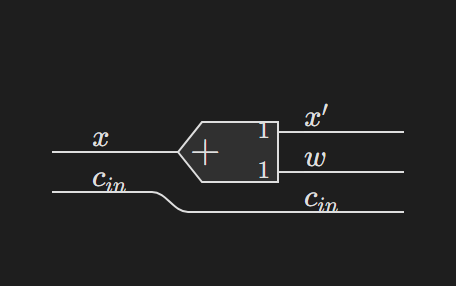

In [2]:
convolution_reindexing = cat.StrideMorphism.from_matrix(
    (1, 1), dom_names=("x'", 'w'), cod_names=('x',), name='+')
input_channels = fd.DynamicName('c', fd.DynamicName('in')).capture(cat.RawAxis())
convolution_matrix = convolution_reindexing * input_channels >> cat.Reals()

read, = convolution_matrix.dom()
written, = convolution_matrix.cod()
assert len(read.shape()) == 2, (
    'the window reads one array over the input positions and the input channels')
assert len(written.shape()) == 3, (
    'it writes one array over the output positions, the window and the channels')
await notebook_diagrams.show_diagram(
    convolution_matrix,
    "The window. Output position x' and offset w read input position x, and the "
    'input channels are carried through untouched.',
    settings=DIAGRAMS)

## The weight applied to each window

`ops.Linear.template(2, c_out)` consumes the last two axes of its operand, the
window and the input channels, and produces the output channels. Composing it
after the window gives the convolution: one array of input positions and input
channels in, one array of output positions and output channels out.

The convolution. The weight consumes the window and the input channels at every output position.


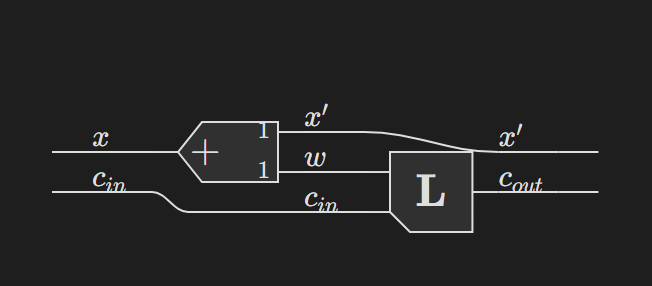

In [3]:
output_channels = fd.DynamicName('c', fd.DynamicName('out')).capture(cat.RawAxis())
convolution = convolution_matrix @ ops.Linear.template(2, output_channels)

returned, = convolution.cod()
assert len(returned.shape()) == 2, (
    'the convolution writes one array over the output positions and output channels')
assert returned.shape()[1] == output_channels, (
    'the second axis of the result is the output channel axis of the weight')
await notebook_diagrams.show_diagram(
    convolution,
    'The convolution. The weight consumes the window and the input channels at '
    'every output position.',
    settings=DIAGRAMS)